# Result Graphs
1. Delta-error comparison (ours vs paper, per method)
2. GPU-hours vs accuracy scatter

In [1]:
import os
import sys

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
results = pd.read_csv("results/results.csv")
results["accuracy_pct"] = results["accuracy"] * 100
results["error_pct"] = 100 - results["accuracy_pct"]

baseline_error = results.loc[results["model"] == "baseline", "error_pct"].values[0]
results["delta_err"] = results["error_pct"] - baseline_error
print(results[["model", "accuracy_pct", "error_pct", "delta_err", "gpu_hours"]])

       model  accuracy_pct  error_pct  delta_err  gpu_hours
0   baseline       38.0933    61.9067     0.0000     0.0916
1     CVP-F3       25.6961    74.3039    12.3972     3.0620
2     CVP-R3       28.7381    71.2619     9.3552     1.5501
3  SVP-Patch       38.0929    61.9071     0.0004     2.3438
4    SVP-Pad       38.0921    61.9079     0.0012     2.3433
5         FT       42.1531    57.8469    -4.0598     3.6045
6        PFT       41.8409    58.1591    -3.7476     8.9503


## Chart 1: Delta-Error Comparison (Ours vs Paper)

In [3]:
methods = ["FT", "PFT", "SVP-Patch", "SVP-Pad", "CVP-F3", "CVP-R3"]
labels = ["FT", "PFT", "SVP-Patch", "SVP-Pad", "CVP-F", "CVP-R"]

model_map = {
    "FT": "FT",
    "PFT": "PFT",
    "SVP-Patch": "SVP-Patch",
    "SVP-Pad": "SVP-Pad",
    "CVP-F3": "CVP-F3",
    "CVP-R3": "CVP-R3",
}

ours_delta = {
    m: results.loc[results["model"] == m, "delta_err"].values[0] for m in methods
}

paper_delta = {
    "FT": +0.95,
    "PFT": +0.34,
    "SVP-Patch": +0.70,
    "SVP-Pad": +0.06,
    "CVP-F3": -2.60,
    "CVP-R3": -2.80,
}

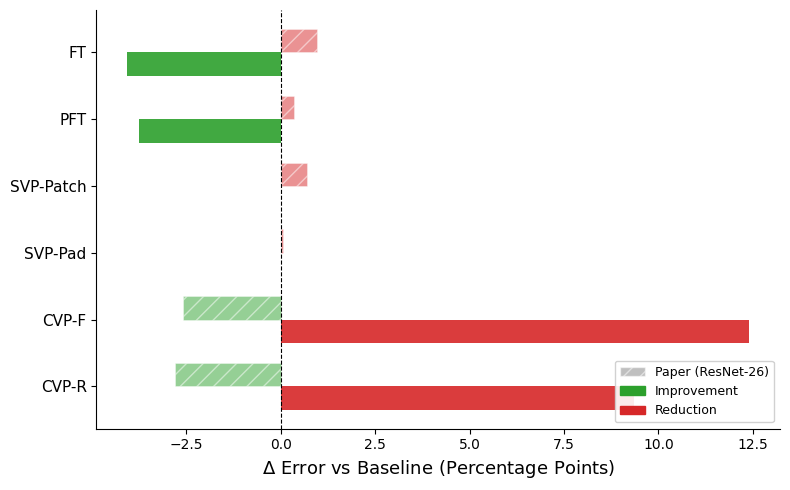

In [4]:
def bar_color(val):
    return "#2ca02c" if val < -0.05 else ("#d62728" if val > 0.05 else "#7f7f7f")


fig, ax = plt.subplots(figsize=(8, 5))

n = len(methods)
y = np.arange(n)
h = 0.35

for i, m in enumerate(methods):
    ours = ours_delta[m]
    paper = paper_delta[m]
    ax.barh(
        y[i] + h / 2,
        ours,
        h,
        color=bar_color(ours),
        alpha=0.9,
        label="Ours" if i == 0 else "",
    )
    ax.barh(
        y[i] - h / 2,
        paper,
        h,
        color=bar_color(paper),
        alpha=0.5,
        label="Paper" if i == 0 else "",
        hatch="//",
        edgecolor="white",
        linewidth=0.5,
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("$\\Delta$ Error vs Baseline (Percentage Points)", fontsize=13)
ax.invert_yaxis()

green_patch = mpatches.Patch(color="#2ca02c", label="Improvement")
red_patch = mpatches.Patch(color="#d62728", label="Reduction")
hatch_patch = mpatches.Patch(
    facecolor="gray",
    alpha=0.5,
    hatch="//",
    edgecolor="white",
    label="Paper (ResNet-26)",
)
ax.legend(
    handles=[hatch_patch, green_patch, red_patch],
    loc="lower right",
    fontsize=9,
    framealpha=0.9,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "delta_error_comparison.pdf"), bbox_inches="tight")
plt.savefig(
    os.path.join(OUT_DIR, "delta_error_comparison.png"), bbox_inches="tight", dpi=200
)
plt.show()

## Chart 2: GPU-Hours vs Accuracy Scatter

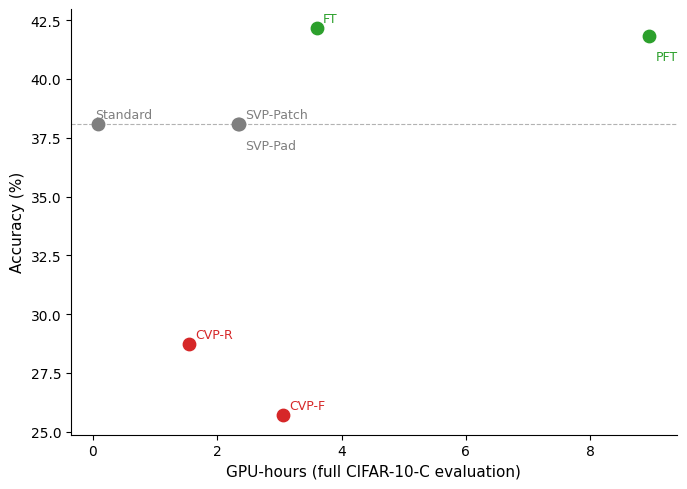

In [6]:
scatter_models = ["baseline", "FT", "PFT", "SVP-Patch", "SVP-Pad", "CVP-F3", "CVP-R3"]
scatter_labels = ["Standard", "FT", "PFT", "SVP-Patch", "SVP-Pad", "CVP-F", "CVP-R"]

colors = {
    "baseline": "#7f7f7f",
    "FT": "#2ca02c",
    "PFT": "#2ca02c",
    "SVP-Patch": "#7f7f7f",
    "SVP-Pad": "#7f7f7f",
    "CVP-F3": "#d62728",
    "CVP-R3": "#d62728",
}

label_offsets = {
    "baseline": (-0.05, 0.4),
    "FT": (0.10, 0.4),
    "PFT": (0.10, -0.9),
    "SVP-Patch": (0.10, 0.4),
    "SVP-Pad": (0.10, -0.9),
    "CVP-F3": (0.10, 0.4),
    "CVP-R3": (0.10, 0.4),
}

fig, ax = plt.subplots(figsize=(7, 5))

for m, lab in zip(scatter_models, scatter_labels):
    row = results.loc[results["model"] == m].iloc[0]
    x, y = row["gpu_hours"], row["accuracy_pct"]
    ax.scatter(x, y, color=colors[m], s=80, zorder=3)
    dx, dy = label_offsets[m]
    ax.annotate(
        lab, (x, y), xytext=(x + dx, y + dy), fontsize=9, color=colors[m], va="center"
    )

ax.axhline(
    results.loc[results["model"] == "baseline", "accuracy_pct"].values[0],
    color="#7f7f7f",
    linewidth=0.8,
    linestyle="--",
    alpha=0.6,
)

ax.set_xlabel("GPU-hours (full CIFAR-10-C evaluation)", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "compute_vs_accuracy.pdf"), bbox_inches="tight")
plt.savefig(
    os.path.join(OUT_DIR, "compute_vs_accuracy.png"), bbox_inches="tight", dpi=200
)
plt.show()